# Módulo 1 — Dia 1
## Modelagem Computacional & Primeiros Passos no Ambiente

Neste notebook vamos percorrer, na prática, o **ciclo de modelagem computacional** aplicado a um
problema simples: uma bola em queda livre.

**Ciclo de modelagem:**

`Problema real → Modelo matemático → Método numérico → Algoritmo → Código → Validação / Análise de erros`

> Dica: execute as células na ordem, de cima para baixo (Shift+Enter).

## 1. Problema real

*"Uma bola é solta do repouso de uma altura h. Quanto tempo leva para atingir o chão, e com que
velocidade?"*

**Hipótese simplificadora:** vamos desprezar a resistência do ar.

## 2. Modelo matemático

$$\frac{d^2y}{dt^2} = -g, \qquad y(0) = h, \quad v(0) = 0$$

## 3. Método numérico

Este caso tem solução analítica direta:

$$y(t) = h - \tfrac{1}{2} g t^2 \qquad\Longrightarrow\qquad t_{queda} = \sqrt{\frac{2h}{g}}, \quad v_{impacto} = g \cdot t_{queda}$$

## 4. Algoritmo

1. Ler a altura `h`.
2. Calcular `t_queda = sqrt(2h/g)`.
3. Calcular `v_impacto = g * t_queda`.
4. Exibir os resultados.

## 5. Código

In [1]:
import math

g = 9.81  # aceleração da gravidade (m/s^2)
h = 5.0   # altura inicial (m)

t_queda = math.sqrt(2 * h / g)
v_impacto = g * t_queda

print(f"Tempo de queda: {t_queda:.2f} s")
print(f"Velocidade de impacto: {v_impacto:.2f} m/s")


Tempo de queda: 1.01 s
Velocidade de impacto: 9.90 m/s


## 6. Validação

Comparar com um caso conhecido: para h = 5 m, esperamos t ≈ 1,01 s.

A resistência do ar que desprezamos na hipótese simplificadora é uma **fonte de erro do modelo**
(diferente dos erros numéricos que veremos no Dia 3).

In [2]:
# validação simples
valor_esperado = 1.01
erro_absoluto = abs(t_queda - valor_esperado)
print(f"t_queda calculado = {t_queda:.4f} s")
print(f"erro absoluto em relação ao valor de referência = {erro_absoluto:.4f} s")
assert erro_absoluto < 0.01, "resultado fora do esperado — revise o cálculo"
print("Validação OK!")


t_queda calculado = 1.0096 s
erro absoluto em relação ao valor de referência = 0.0004 s
Validação OK!


---
## Exercício 1 — Generalizando o código

Modifique o código abaixo para:

1. Receber a altura `h` a partir de uma variável (ou de `input()`, se estiver rodando localmente).
2. Testar com pelo menos **três valores diferentes** de `h`.
3. Comparar os resultados com a sua intuição física (uma bola solta de um prédio de 20 m deveria
   demorar mais para cair do que uma solta de uma mesa de 1 m?).

In [3]:
def tempo_e_velocidade_de_queda(altura, g=9.81):
    """
    Calcula o tempo de queda e a velocidade de impacto de um objeto em queda livre.

    Parâmetros
    ----------
    altura : float
        Altura inicial em metros.
    g : float, opcional
        Aceleração da gravidade em m/s^2 (padrão: 9.81).

    Retorna
    -------
    tuple (float, float)
        Tempo de queda (s) e velocidade de impacto (m/s).
    """
    # TODO: implemente aqui (reaproveite o cálculo da seção 5)
    t = math.sqrt(2 * altura / g)
    v = g * t
    return t, v


# Teste com pelo menos 3 valores de altura
alturas_teste = [1.0, 5.0, 20.0]  # TODO: use seus próprios valores também

for h_teste in alturas_teste:
    t, v = tempo_e_velocidade_de_queda(h_teste)
    print(f"h = {h_teste:5.1f} m  ->  t = {t:.2f} s   v = {v:.2f} m/s")


h =   1.0 m  ->  t = 0.45 s   v = 4.43 m/s
h =   5.0 m  ->  t = 1.01 s   v = 9.90 m/s
h =  20.0 m  ->  t = 2.02 s   v = 19.81 m/s


## Desafio opcional — Resistência do ar

Pesquise a fórmula da velocidade de um corpo em queda livre **com resistência do ar linear**:

$$v(t) = v_{terminal} \left(1 - e^{-kt/m}\right)$$

Implemente-a abaixo e compare qualitativamente com o resultado sem resistência do ar. Você pode
escolher valores arbitrários e razoáveis para `v_terminal`, `k` e `m` — o objetivo é observar o
comportamento, não obter um valor numérico específico.

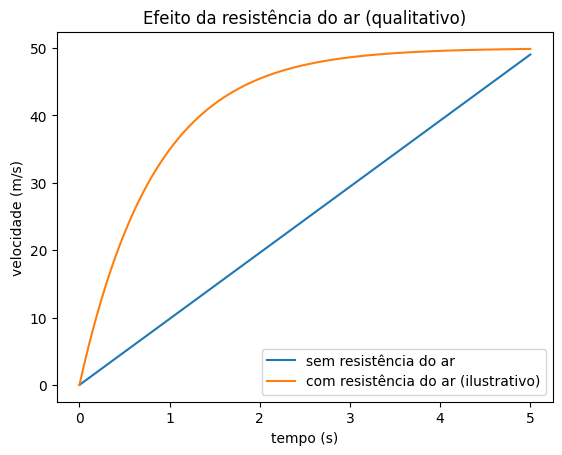

In [4]:
import numpy as np
import matplotlib.pyplot as plt

v_terminal = 50.0  # m/s (valor ilustrativo)
k_sobre_m = 1.2     # 1/s (valor ilustrativo, equivale a k/m)

t = np.linspace(0, 5, 200)
v_com_resistencia = v_terminal * (1 - np.exp(-k_sobre_m * t))
v_sem_resistencia = g * t

plt.plot(t, v_sem_resistencia, label="sem resistência do ar")
plt.plot(t, v_com_resistencia, label="com resistência do ar (ilustrativo)")
plt.xlabel("tempo (s)")
plt.ylabel("velocidade (m/s)")
plt.title("Efeito da resistência do ar (qualitativo)")
plt.legend()
plt.show()


---
## Anote suas conclusões

Escreva, nesta célula (dê duplo clique para editar), 2–3 linhas relacionando o que você observou
no gráfico acima com as etapas do ciclo de modelagem computacional.

*(resposta do aluno aqui)*